In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("final_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])

In [5]:
#drop source col
df.drop(columns=['source'], inplace=True)

In [6]:
#drop rows with no date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.dropna(subset=['Date'], inplace=True)

In [10]:
#interpolate missing prices and volume
cols = ['Close','High','Low','Open','Volume']
daily= df.groupby('Date')[cols].mean().reset_index()
daily['Date'] = pd.to_datetime(daily['Date'])
daily.set_index('Date', inplace=True)
daily[cols] = daily[cols].interpolate(method='time')
for col in cols:
    df[col] = df['Date'].map(daily[col])

In [11]:
#missing sentiments
missing_headlines = df['title'].isna()
df.loc[missing_headlines, ['negative','positive']] = 0
df.loc[missing_headlines, ['neutral']] = 1

In [12]:
#forwrad fill for interest rate and inflation
df[['interest_rate', 'inflation']] = df[['interest_rate', 'inflation']].fillna(method='ffill')

C:\Users\Dell\AppData\Local\Temp\ipykernel_14784\1984539751.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[['interest_rate', 'inflation']] = df[['interest_rate', 'inflation']].fillna(method='ffill')


In [13]:
#interpolate (time based) for usd index
usd_index_daily = df.groupby('Date')['usd_index'].mean() 
usd_index_daily = usd_index_daily.interpolate(method='time')
df['usd_index'] = df['Date'].map(usd_index_daily)

In [14]:
#handle missing headlines
df['title'] = df['title'].fillna('no headline')

In [15]:
#renaming
df.rename(columns={'Date': 'date'}, inplace=True)
df.rename(columns={'Close': 'close'}, inplace=True)
df.rename(columns={'High': 'high'}, inplace=True)
df.rename(columns={'Low': 'low'}, inplace=True)
df.rename(columns={'Open': 'open'}, inplace=True)
df.rename(columns={'Volume': 'volume'}, inplace=True)
df.rename(columns={'title': 'headline'}, inplace=True)

In [16]:
#cleaned csv
df.to_csv('cleaned_dataset.csv', index=False)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23693 entries, 0 to 23692
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              23693 non-null  datetime64[ns]
 1   close             23693 non-null  float64       
 2   high              23693 non-null  float64       
 3   low               23693 non-null  float64       
 4   open              23693 non-null  float64       
 5   volume            23693 non-null  float64       
 6   headline          23693 non-null  object        
 7   negative          23693 non-null  float64       
 8   neutral           23693 non-null  float64       
 9   positive          23693 non-null  float64       
 10  interest_rate     23693 non-null  float64       
 11  inflation         23693 non-null  float64       
 12  usd_index         23693 non-null  float64       
 13  season            23693 non-null  object        
 14  year              23693 non

In [19]:
#one hot encoding season
df = pd.read_csv('cleaned_dataset.csv')

season_dummies = pd.get_dummies(df['season'], prefix='season')
df = pd.concat([df, season_dummies], axis=1)
df.drop(columns=['season'], inplace=True)
df.to_csv('cleaned_dataset.csv', index=False)

In [48]:
#lag and rolling feature
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
daily_close = df.groupby('date')['close'].mean().reset_index()

#Lag features
lags = [1, 3, 7, 14, 30]
for lag in lags:
    daily_close[f'Close_lag{lag}'] = daily_close['close'].shift(lag)

#Rolling features
windows = [7, 30]
for window in windows:
    daily_close[f'Close_roll_mean_{window}'] = daily_close['close'].shift(1).rolling(window).mean()

lag_roll_cols = [c for c in daily_close.columns if 'lag' in c or 'roll' in c]
df = df.merge(daily_close[['date'] + lag_roll_cols], on='date', how='left')

#original close val for NaN
for col in lag_roll_cols:
    df[col] = df[col].fillna(df['close'])


In [51]:
#unscaled dataset
df.to_csv("dataset_unscaled.csv", index=False)

In [56]:
print(df.dtypes)

date                  datetime64[ns]
close                        float64
high                         float64
low                          float64
open                         float64
volume                       float64
headline                      object
negative                     float64
neutral                      float64
positive                     float64
interest_rate                float64
inflation                    float64
usd_index                    float64
year                           int64
month                          int64
day                            int64
day_of_week                    int64
week_of_year                   int64
quarter                        int64
is_weekend                     int64
days_since_start               int64
month_sin                    float64
month_cos                    float64
dayofweek_sin                float64
dayofweek_cos                float64
season_Autumn                   bool
season_Spring                   bool
s

In [57]:
#scaling
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = df.copy()  

do_not_scale = [
    "date",        
    "close",       # target
    "headline",    
    "season_Autumn",
    "season_Spring",
    "season_Summer",
    "season_Winter"
]

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# remove target + boolean season columns
numeric_cols = [col for col in numeric_cols if col not in do_not_scale]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df_scaled.to_csv("dataset_scaled.csv", index=False)

print("Scaling done")

Scaling done


        date        close      high       low     open    volume  \
0 2019-03-01  1296.400024 -1.431045 -1.451517 -1.42757 -0.171146   
1 2019-03-01  1296.400024 -1.431045 -1.451517 -1.42757 -0.171146   
2 2019-03-01  1296.400024 -1.431045 -1.451517 -1.42757 -0.171146   
3 2019-03-01  1296.400024 -1.431045 -1.451517 -1.42757 -0.171146   
4 2019-03-01  1296.400024 -1.431045 -1.451517 -1.42757 -0.171146   

                                            headline  negative   neutral  \
0  US wiped some hard drives of Russia's 'troll f... -0.294504 -0.257293   
1  Measles cases at 'alarmingly' high levels arou...  0.244953  1.069480   
2  Tesla debuts $35,000 Model 3, sees loss in fir... -0.529681  1.557302   
3  This is not a day at the beach: Pelosi tells... -0.479691  0.689845   
4  Israeli Prime Minister Benjamin Netanyahu to b... -0.428635  0.997160   

   positive  ...  season_Spring  season_Summer  season_Winter  Close_lag1  \
0  0.443563  ...           True          False          F

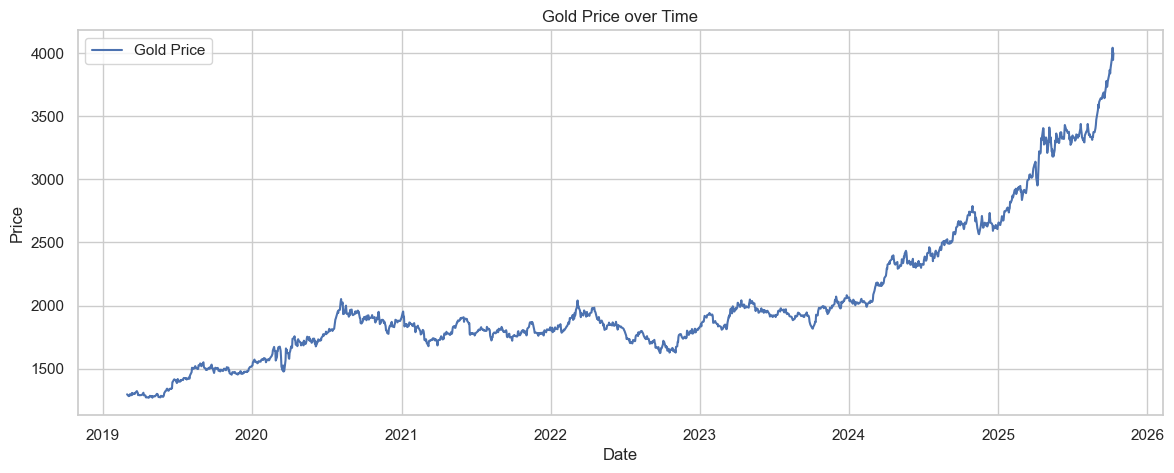

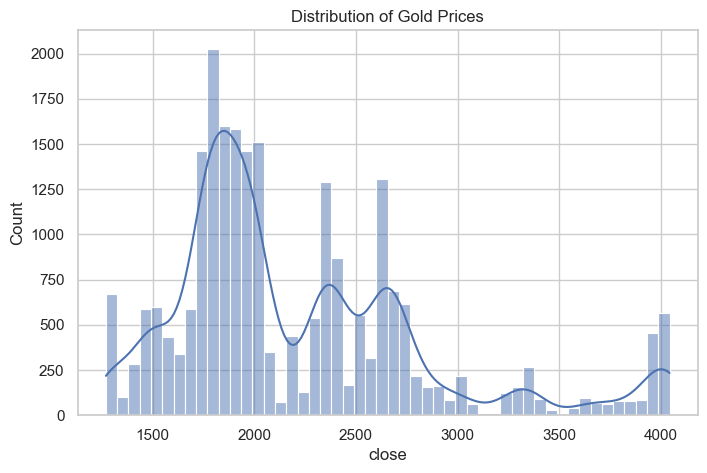

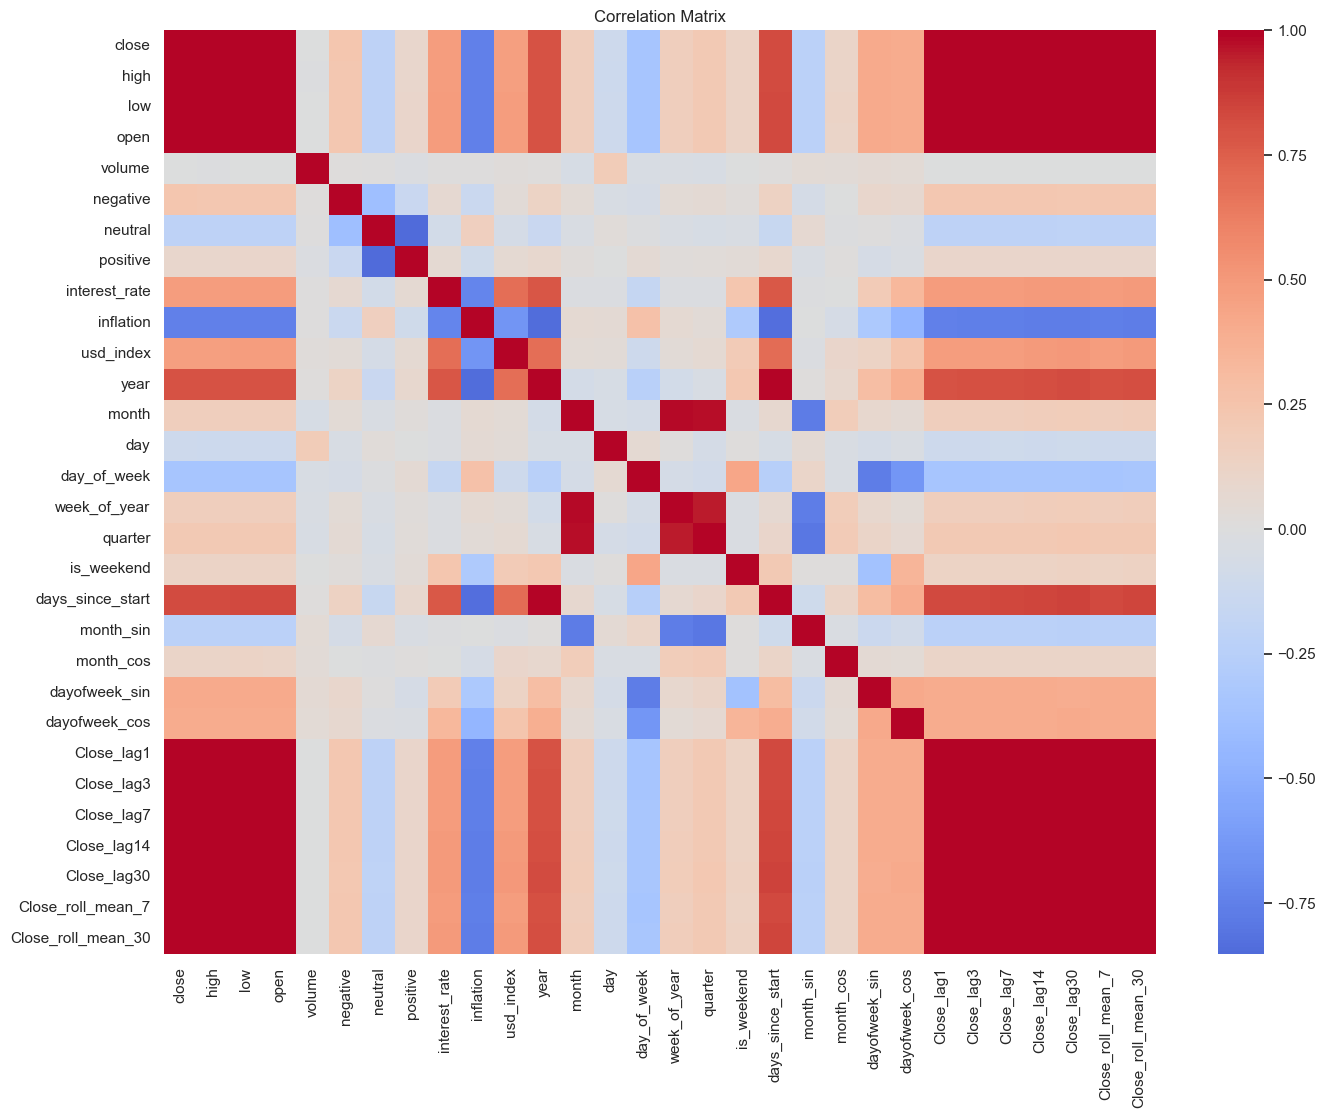

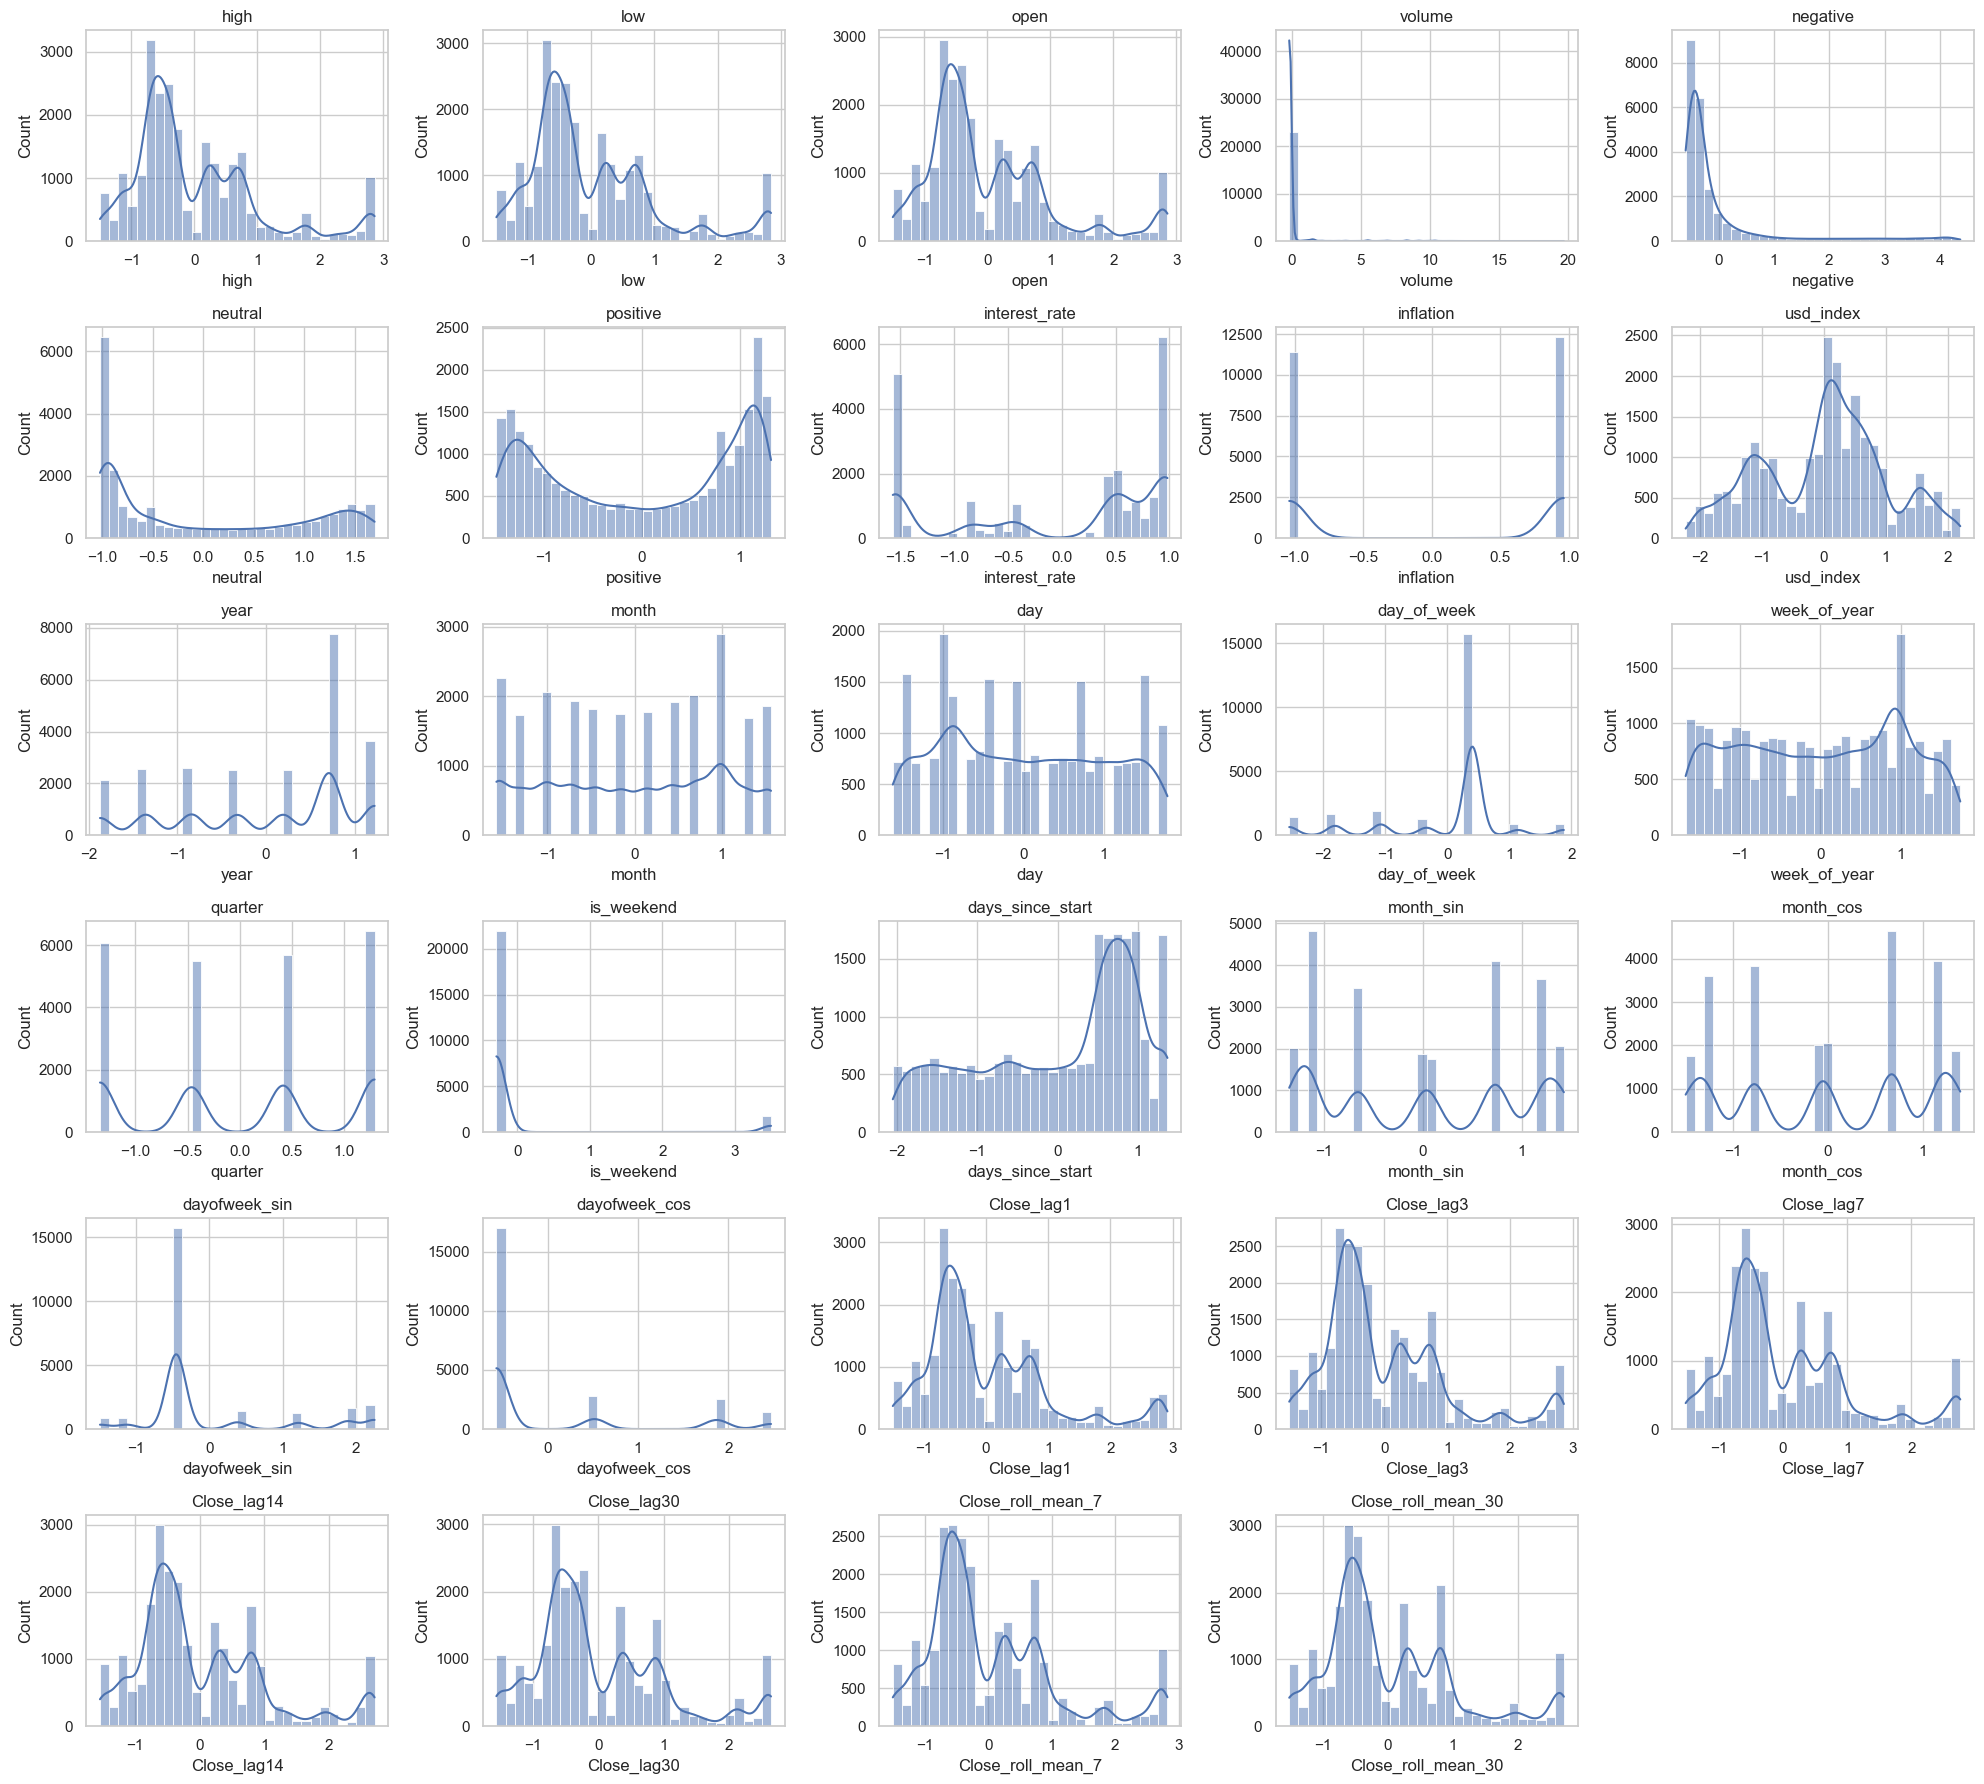

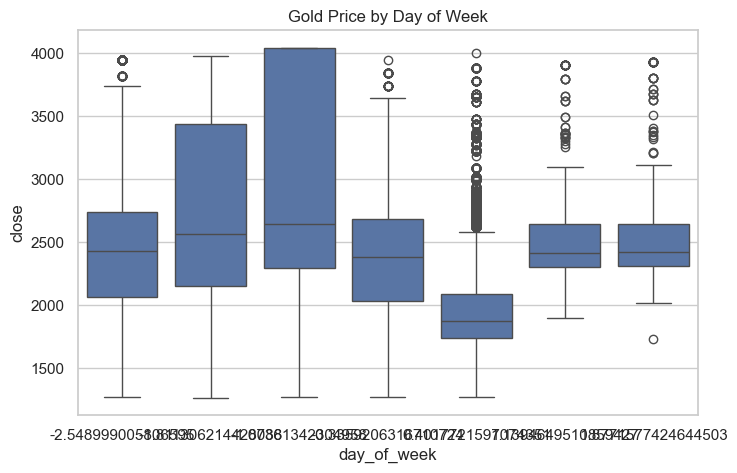

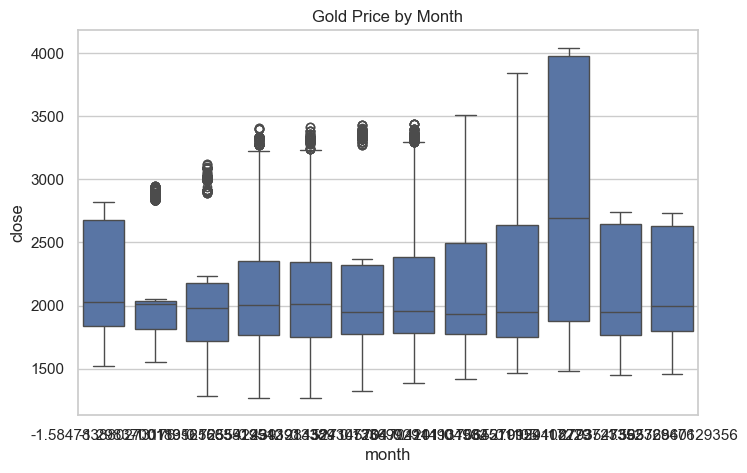

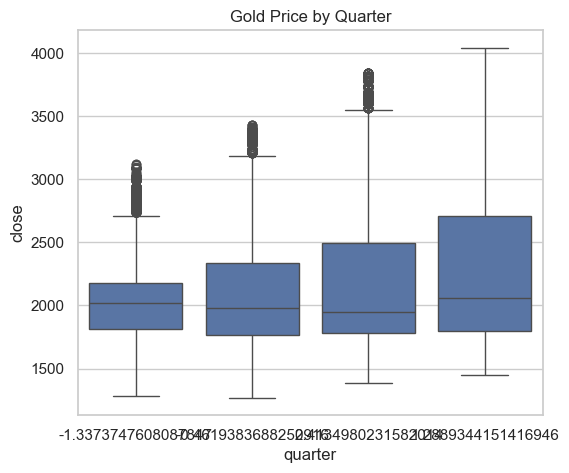

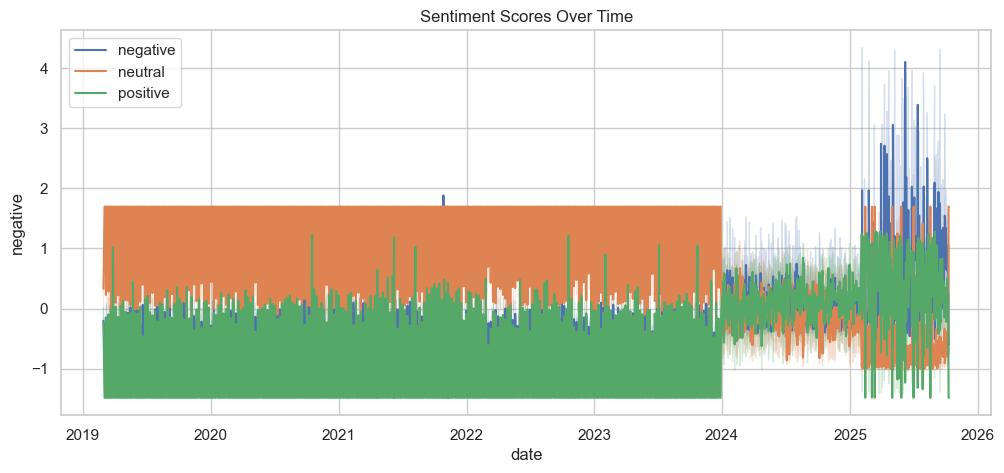

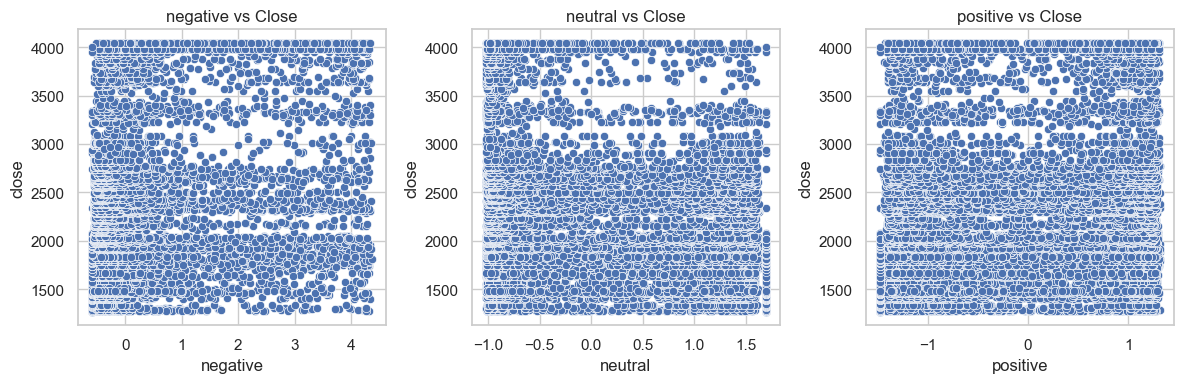

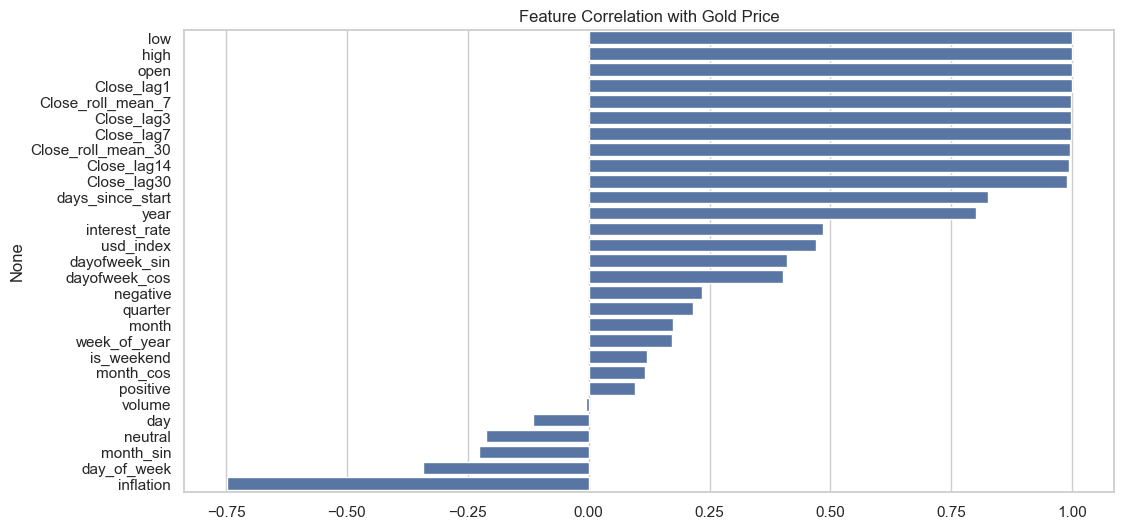

In [64]:
#EDA
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set(style="whitegrid")
%matplotlib inline
df = pd.read_csv("dataset_scaled.csv")  # scaled dataset for EDA
df['date'] = pd.to_datetime(df['date'])
# First rows
print(df.head())
# Info about columns
print(df.info())
# Check for any missing values
print(df.isna().sum())
# Summary statistics
print(df.describe())

plt.figure(figsize=(14,5))
plt.plot(df['date'], df['close'], label='Gold Price')
plt.title("Gold Price over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['close'], bins=50, kde=True)
plt.title("Distribution of Gold Prices")
plt.show()

# Correlation matrix
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

# Histograms of numeric features
numeric_cols = numeric_df.columns.tolist()
numeric_cols.remove('close')  # skip target

num_cols = len(numeric_cols)
cols = 5  
rows = math.ceil(num_cols / cols)

plt.figure(figsize=(cols*4, rows*3))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


#Boxplots for day, month, quarter
plt.figure(figsize=(8,5))
sns.boxplot(x='day_of_week', y='close', data=df)
plt.title("Gold Price by Day of Week")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='month', y='close', data=df)
plt.title("Gold Price by Month")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(x='quarter', y='close', data=df)
plt.title("Gold Price by Quarter")
plt.show()

#Sentiment plots
sent_cols = ['negative', 'neutral', 'positive']

# Sentiment over time
plt.figure(figsize=(12,5))
for col in sent_cols:
    sns.lineplot(x=df['date'], y=df[col], label=col)
plt.title("Sentiment Scores Over Time")
plt.show()

# Scatter sentiment vs Close
plt.figure(figsize=(12,4))
for i, col in enumerate(sent_cols):
    plt.subplot(1,3,i+1)
    sns.scatterplot(x=df[col], y=df['close'])
    plt.title(f"{col} vs Close")
plt.tight_layout()
plt.show()

#Correlation-based feature importance
feature_corr = numeric_df.corr()['close'].drop('close').sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=feature_corr.values, y=feature_corr.index)
plt.title("Feature Correlation with Gold Price")
plt.show()

In [5]:
#KNN with library
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from collections import Counter
from sklearn.neighbors import KNeighborsRegressor

df = pd.read_csv('dataset_scaled.csv')
features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
features.remove('close')

X = df[features].values
y = df['close'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

k = 5  # number of neighbors
knn = KNeighborsRegressor(n_neighbors=k)
knn.fit(X_train, y_train)
y_pred_sklearn = knn.predict(X_test)

# Evaluation
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)
accuracy_sklearn = r2_sklearn * 100


print(f"Scikit-learn KNN - MSE: {mse_sklearn:.4f}, R2: {r2_sklearn:.4f}, Accuracy: {accuracy_sklearn:.4f}")

Scikit-learn KNN - MSE: 771.8815, R2: 0.9981, Accuracy: 99.8088


In [3]:
#custom knn
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

train_subset_size = 5000
test_subset_size = 1000

train_indices = np.random.choice(len(X_train), train_subset_size, replace=False)
test_indices = np.random.choice(len(X_test), test_subset_size, replace=False)

X_train_small = X_train[train_indices]
y_train_small = y_train[train_indices]

X_test_small = X_test[test_indices]
y_test_small = y_test[test_indices]

print(f"Subset selected: {train_subset_size} train rows, {test_subset_size} test rows")

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict_custom(X_train, y_train, X_test, k=5):
    y_pred = []
    for i, x in enumerate(X_test):
        if (i+1) % 50 == 0:  # print every 50 test samples
            print(f"Predicting sample {i+1}/{len(X_test)}...")
        # Compute distances to all training points
        distances = [euclidean_distance(x, x_train) for x_train in X_train]
        # Indices of k nearest neighbors
        nn_indices = np.argsort(distances)[:k]
        # Predict as mean of neighbors
        pred = np.mean(y_train[nn_indices])
        y_pred.append(pred)
    return np.array(y_pred)

print("Running custom KNN prediction...")
k = 5
y_pred_custom = knn_predict_custom(X_train_small, y_train_small, X_test_small, k=k)
print("Prediction complete!")

print("Evaluating model...")
mse_custom = mean_squared_error(y_test_small, y_pred_custom)
r2_custom = r2_score(y_test_small, y_pred_custom)
accuracy_custom = r2_custom * 100

print(f"Custom KNN (subset) - MSE: {mse_custom:.4f}, R2: {r2_custom:.4f}, Accuracy: {accuracy_custom:.4f}")

Subset selected: 5000 train rows, 1000 test rows
Running custom KNN prediction...
Predicting sample 50/1000...
Predicting sample 100/1000...
Predicting sample 150/1000...
Predicting sample 200/1000...
Predicting sample 250/1000...
Predicting sample 300/1000...
Predicting sample 350/1000...
Predicting sample 400/1000...
Predicting sample 450/1000...
Predicting sample 500/1000...
Predicting sample 550/1000...
Predicting sample 600/1000...
Predicting sample 650/1000...
Predicting sample 700/1000...
Predicting sample 750/1000...
Predicting sample 800/1000...
Predicting sample 850/1000...
Predicting sample 900/1000...
Predicting sample 950/1000...
Predicting sample 1000/1000...
Prediction complete!
Evaluating model...
Custom KNN (subset) - MSE: 4000.1030, R2: 0.9901, Accuracy: 99.0051


In [4]:
#library and custom code knn comparison
print("\nComparison:")
print(f"{'Method':<20} {'MSE':<12} {'R2':<10} {'Accuracy %':<12}")
print(f"{'Scikit-learn KNN':<20} {mse_sklearn:<12.4f} {r2_sklearn:<10.4f} {accuracy_sklearn:.4f}")
print(f"{'Custom KNN':<20} {mse_custom:<12.4f} {r2_custom:<10.4f} {accuracy_custom:.4f}")


Comparison:
Method               MSE          R2         Accuracy %  
Scikit-learn KNN     771.8815     0.9981     99.8088
Custom KNN           4000.1030    0.9901     99.0051
